In [1]:
import sys
sys.path.append('../../')
from DEDi import PDE_find as PDE
import numpy as np
import matplotlib.pyplot as plt
import time
import jax.numpy as jnp

### KS Equation

$(a,b,c) = (1,-1,-1)$

$$u_t  = a (u u_x) + b u_{xx} + c u_{xxxx} $$

(128, 128)

dx 0.3125 dt 0.3
1.8417222762475243


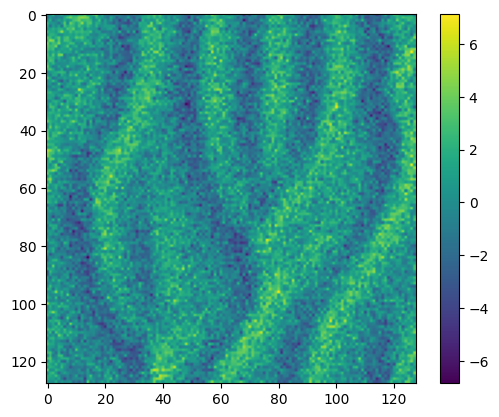

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# grid in x
scale = 1
L = scale * 40  # domain size
N = scale * 128
dx = L / N
x = dx * (np.arange(0, N)) 
# grid in t
M,h,substeps = 128, .01, 30  # number of timesteps in data
dt = h * substeps  # delta t in data is h*substeps
t = dt * np.arange(1, M+1)
X, T = np.meshgrid(x, t)

# wave numbers etc. for spectral diff
k = np.fft.fftfreq(N, d=dx) * 2 * np.pi
k2 = -k**2  # spectral laplacian
k4 = k2**2  # spectral bilaplacian

# KS parameters u_t = a (u u_x) - b u_xx - c*u_xxxx
a,b,c,C = 1,-1,-1,-1

r1,r2 = -2,2
U = r1 * np.sin(12 * np.pi * x / L) + r2 * np.exp(-(x - 2)**2 / 5)  # initial data
U = U
Uh,u_total = np.fft.fft(U),np.zeros((M, N))

for j in range(M):
    for step in range(substeps):
        du, Unew = 1e10, U
        Uhnew = np.fft.fft(Unew)  # initial guess for iteration
        while du > 1e-8:  # iterate to obtain trapezoid rule for each substep
            Ubar = 0.5 * (U + Unew)
            Uhbar = np.fft.fft(Ubar)
            R = Uh +  h * np.fft.fft(a * Ubar * np.real(np.fft.ifft(1j * k * Uhbar)) + b * np.fft.ifft(k2 * Uhbar) + c * np.fft.ifft(k4 * Uhbar) - C * np.fft.ifft(k4 * Uhnew))
            Uhnew = R / (1 - h * C * k4)
            Unew2 = np.real(np.fft.ifft(Uhnew))
            du = np.linalg.norm(Unew2 - Unew)
            Unew = Unew2
        U = Unew
        Uh = np.fft.fft(U)
    u_total[j, :] = U

np.random.seed(1)
percent_noise = 1.0
u_noise = u_total + np.random.normal(0,np.std(u_total)*percent_noise,size=u_total.shape)
print(np.shape(u_noise))
plt.imshow(u_noise)
plt.colorbar()

In [3]:
## If you want to mask the states
FractionOfDataMissing = 0.0
NumOfDataMissing = int(np.size(u_noise)*FractionOfDataMissing)
state_mask = np.ones(np.size(u_noise)).astype(bool)
state_mask[:NumOfDataMissing] = False
np.random.shuffle(state_mask)
state_mask = np.reshape(state_mask,np.shape(u_noise))
u_noise = u_noise*state_mask #Just to show it is truly masking this data

In [4]:
symbols = ['u_xx','u_xxxx','u u_x','u','u^2','u^3','u_x','u_xxx','u^2 u_x']

TRange, XRange = [t[0],t[-1]], [x[0],x[-1]]

trial = PDE(u_noise,symbols,TRange, XRange,
             state_mask=state_mask, smooth_init_states = None,
             init_params = None,
             cpu_or_gpu = 'gpu')

Setting Up Sparse Structure


In [ ]:
objectives = [1e-1,1e-4]
guess = trial.FindBestModel(objective_params = objectives,
                                     tolerance = 1e-6,verbose=True,
                                     max_iterations = 500,method = "LM",
                                     info_criteria='BIC',
                                     drop_method = {"initial":'single',"k":3},
                                     LA_solver = "cholesky")

Solver Error = 2363494524.431497
Solver Error = 2363494524.4314947
1 | f = 121467172.552282, ||df|| = 2.363e+09, Alpha = 3.000e+00, SolverTime = 0.171s, HessianTime = 0.000s
1 | f = 121467172.552281, ||df|| = 2.363e+09, Alpha = 3.000e+00, SolverTime = 0.183s, HessianTime = 0.003s
[ 1.214  0.1   -0.1    0.1    0.1    0.1    0.1    0.1    0.1    0.1  ]
[ 1.214  0.1   -0.1    0.1    0.1    0.1    0.1    0.1    0.1    0.1  ]
Solver Error = 2.463834425397246e-07
Solver Error = 1.918548875213694e-06
2 | f = 26657412.397219, ||df|| = 4.643e+08, Alpha = 6.000e-01, SolverTime = 0.072s, HessianTime = 0.001s
[ 4.28   0.207 -0.105  0.043  0.257  0.069 -0.059  0.223  0.095  0.075]
2 | f = 26657412.397232, ||df|| = 4.643e+08, Alpha = 6.000e-01, SolverTime = 0.137s, HessianTime = 0.001s
[ 4.28   0.207 -0.105  0.043  0.257  0.069 -0.059  0.223  0.095  0.075]
Solver Error = 464347825.5820605
3 | f = 26657412.397219, ||df|| = 4.643e+08, Alpha = 1.800e+00, SolverTime = 0.067s, HessianTime = 0.000s
Solver

In [ ]:
models,latex = trial.PrintModels(return_latex=True,ICCutoff=0)
latex

<IPython.core.display.Latex object>

'\\begin{align*}Rel IC &= 0.0\\\\Likelyhood &= 2854.9834453755475\\\\\\ u_t &= -0.979u_{xx} - 0.991u_{xxxx} + 0.986u u_{x} \\\\\\end{align*}'

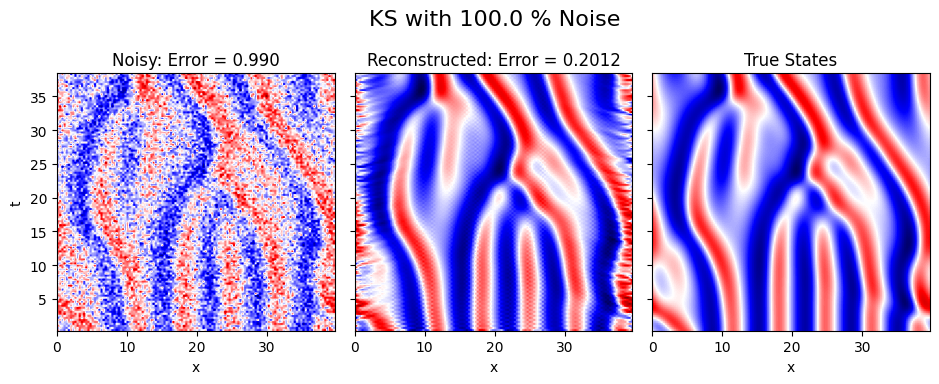

In [ ]:
opt_states,opt_params = trial.unravel_states_and_parameters(trial.states_and_parameters)
state_mask = trial.state_mask

Noisy_error = np.linalg.norm(u_noise - u_total)/np.linalg.norm(u_total)
Reconstructed_error = np.linalg.norm(opt_states - u_total)/np.linalg.norm(u_total)

min_val = min( np.min(opt_states), np.min(u_total))
max_val = max( np.max(opt_states), np.max(u_total))
cmap = 'seismic'

##Overlay
fig, axs = plt.subplots(1, 3, figsize=(10, 4),sharey=True)  # 1 row, 2 columns
axs[0].imshow(u_noise, extent=[x[0], x[-1], t[0], t[-1]], origin='lower', aspect='auto',cmap = cmap)
axs[0].set_title(f'Noisy: Error = {Noisy_error:.3f}')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')  # Y-axis label only on the first (leftmost) plot

axs[1].imshow(opt_states, extent=[x[0], x[-1], t[0], t[-1]], origin='lower', aspect='auto',cmap = cmap, vmin=min_val, vmax=max_val)
axs[1].set_title(f'Reconstructed: Error = {Reconstructed_error:.4f}')
axs[1].set_xlabel('x')

axs[2].imshow(u_total, extent=[x[0], x[-1], t[0], t[-1]], origin='lower', aspect='auto', cmap = cmap,vmin=min_val, vmax=max_val)
axs[2].set_title(f'True States')
axs[2].set_xlabel('x')

plt.suptitle(f'KS with {percent_noise*100} % Noise', fontsize=16)
plt.tight_layout(rect=[0, 0.03, .95, 1]) 
fig.show()